In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch, json

class Config:
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    DATA_DIR        = os.path.join(PROJECT_ROOT, 'data')
    DOCVQA_DIR      = os.path.join(DATA_DIR, 'docvqa')
    FINANCIAL_ANNOT = os.path.join(DATA_DIR, 'financial_test/annotations')
    FINANCIAL_IMGS  = os.path.join(DATA_DIR, 'financial_test/images/manual')
    MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
    PIX2STRUCT_ID   = 'google/pix2struct-docvqa-base'
    LORA_RANK       = 16
    LORA_ALPHA      = 32
    LEARNING_RATE   = 5e-5
    WEIGHT_DECAY    = 0.01
    EPOCHS          = 5
    BATCH_SIZE      = 2
    GRAD_ACCUM      = 4
    SEED            = 42

cfg = Config()
torch.manual_seed(cfg.SEED)

print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ GPU: Tesla T4
  Memory: 15.6 GB


In [2]:
# ============================================================
# CELL 2: Install dependencies
# ============================================================

%%capture
!pip install transformers==4.44.2 accelerate datasets sentencepiece protobuf
!pip install peft bitsandbytes

In [3]:
# ============================================================
# CELL 3: Load DocVQA training data
# ============================================================

from datasets import load_from_disk
import numpy as np

print("Loading DocVQA from Drive...")
docvqa = load_from_disk(os.path.join(cfg.DOCVQA_DIR, 'docvqa_dataset'))
print(f"✓ DocVQA: {len(docvqa['train'])} train, {len(docvqa['validation'])} val")

# Use 5000 training examples (full dataset too slow for Colab)
np.random.seed(cfg.SEED)
train_indices = np.random.choice(len(docvqa['train']), 5000, replace=False)
val_indices = np.random.choice(len(docvqa['validation']), 500, replace=False)

train_data = docvqa['train'].select(train_indices)
val_data = docvqa['validation'].select(val_indices)

print(f"✓ Training subset: {len(train_data)}")
print(f"✓ Validation subset: {len(val_data)}")

Loading DocVQA from Drive...


Loading dataset from disk:   0%|          | 0/59 [00:00<?, ?it/s]

✓ DocVQA: 39463 train, 5349 val
✓ Training subset: 5000
✓ Validation subset: 500


In [4]:
# ============================================================
# CELL 4: Load Pix2Struct + Apply LoRA
# ============================================================

from transformers import Pix2StructProcessor, Pix2StructForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType

print("Loading Pix2Struct...")
processor = Pix2StructProcessor.from_pretrained(cfg.PIX2STRUCT_ID)
model = Pix2StructForConditionalGeneration.from_pretrained(cfg.PIX2STRUCT_ID)

# Debug: find correct attention module names
print("\nSearching for attention modules...")
attention_names = []
for name, _ in model.named_modules():
    if any(x in name.lower() for x in ['query', 'value', 'q_proj', 'v_proj', 'k_proj']):
        attention_names.append(name)
        print(f"  Found: {name}")

if not attention_names:
    print("  ⚠️ No standard attention modules found. Listing all modules with 'attention':")
    for name, _ in model.named_modules():
        if 'attention' in name.lower():
            print(f"    {name}")

# Apply LoRA
print("\nApplying LoRA...")
lora_config = LoraConfig(
    r=cfg.LORA_RANK,
    lora_alpha=cfg.LORA_ALPHA,
    target_modules=["query", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(model, lora_config)
model = model.to('cuda')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"\n✓ LoRA applied")
print(f"  Total parameters:     {total / 1e6:.1f}M")
print(f"  Trainable parameters: {trainable / 1e6:.1f}M")
print(f"  Trainable %:          {trainable / total * 100:.2f}%")

if trainable == 0:
    print("  ⚠️ WARNING: No trainable parameters! LoRA target_modules may be wrong.")
elif trainable / total > 0.05:
    print("  ⚠️ WARNING: Trainable % seems high. Expected 1-2%.")
else:
    print("  ✓ Looks correct")

Loading Pix2Struct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



Searching for attention modules...
  Found: encoder.encoder.layer.0.attention.query
  Found: encoder.encoder.layer.0.attention.value
  Found: encoder.encoder.layer.1.attention.query
  Found: encoder.encoder.layer.1.attention.value
  Found: encoder.encoder.layer.2.attention.query
  Found: encoder.encoder.layer.2.attention.value
  Found: encoder.encoder.layer.3.attention.query
  Found: encoder.encoder.layer.3.attention.value
  Found: encoder.encoder.layer.4.attention.query
  Found: encoder.encoder.layer.4.attention.value
  Found: encoder.encoder.layer.5.attention.query
  Found: encoder.encoder.layer.5.attention.value
  Found: encoder.encoder.layer.6.attention.query
  Found: encoder.encoder.layer.6.attention.value
  Found: encoder.encoder.layer.7.attention.query
  Found: encoder.encoder.layer.7.attention.value
  Found: encoder.encoder.layer.8.attention.query
  Found: encoder.encoder.layer.8.attention.value
  Found: encoder.encoder.layer.9.attention.query
  Found: encoder.encoder.layer.9.

In [5]:
# ============================================================
# CELL 5: Train with memory optimizations (FIXED OOM v2)
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import gc

torch.cuda.empty_cache()
gc.collect()

MAX_PATCHES = 1024
BATCH_SIZE = 1
GRAD_ACCUM = 8

class DocVQADataset(Dataset):
    def __init__(self, hf_dataset, processor, max_patches=1024):
        self.data = hf_dataset
        self.processor = processor
        self.max_patches = max_patches

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]

        img = example['image']
        if isinstance(img, dict) and 'bytes' in img:
            img = Image.open(BytesIO(img['bytes']))
        img = img.convert('RGB')

        max_dim = 1024
        if max(img.size) > max_dim:
            img.thumbnail((max_dim, max_dim))

        question = example['question']
        answer = example['answers'][0] if example['answers'] else ""

        encoding = self.processor(
            images=img,
            text=question,
            return_tensors="pt",
            max_patches=self.max_patches,
        )

        labels = self.processor.tokenizer(
            answer,
            return_tensors="pt",
            padding="max_length",
            max_length=32,
            truncation=True,
        ).input_ids

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            'flattened_patches': encoding.flattened_patches.squeeze(0),
            'attention_mask': encoding.attention_mask.squeeze(0),
            'labels': labels.squeeze(0),
        }

def collate_fn(batch):
    return {
        'flattened_patches': torch.stack([x['flattened_patches'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch]),
    }

print("Preparing datasets...")
train_dataset = DocVQADataset(train_data, processor, max_patches=MAX_PATCHES)
val_dataset = DocVQADataset(val_data, processor, max_patches=MAX_PATCHES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"✓ Train batches: {len(train_loader)}")
print(f"✓ Val batches: {len(val_loader)}")
print(f"✓ Max patches: {MAX_PATCHES}")
print(f"✓ Batch size: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY
)

save_path = os.path.join(cfg.MODELS_DIR, 'pix2struct_lora_best')
os.makedirs(save_path, exist_ok=True)

print(f"\nStarting training...")
print(f"  Epochs: {cfg.EPOCHS}")
print(f"  Learning rate: {cfg.LEARNING_RATE}")
print(f"  LoRA rank: {cfg.LORA_RANK}, alpha: {cfg.LORA_ALPHA}")
print("=" * 60)

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(cfg.EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS} [Train]")):
        batch = {k: v.to('cuda') for k, v in batch.items()}

        outputs = model.base_model.model(
            flattened_patches=batch['flattened_patches'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels'],
        )
        loss = outputs.loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += outputs.loss.item()

        if step % 200 == 0:
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS} [Val]"):
            batch = {k: v.to('cuda') for k, v in batch.items()}
            outputs = model.base_model.model(
                flattened_patches=batch['flattened_patches'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels'],
            )
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"\n  Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        model.save_pretrained(save_path)
        processor.save_pretrained(save_path)
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/3)")
        if patience_counter >= 3:
            print("  Early stopping triggered")
            break

print("\n✓ Training complete!")
print(f"  Best validation loss: {best_val_loss:.4f}")

curves = {'train_losses': train_losses, 'val_losses': val_losses}
with open(os.path.join(cfg.OUTPUTS_DIR, 'training_curves.json'), 'w') as f:
    json.dump(curves, f)
print("✓ Training curves saved")

Preparing datasets...
✓ Train batches: 5000
✓ Val batches: 500
✓ Max patches: 1024
✓ Batch size: 1 x 8 = 8

Starting training...
  Epochs: 5
  Learning rate: 5e-05
  LoRA rank: 16, alpha: 32


Epoch 1/5 [Val]: 100%|██████████| 500/500 [05:21<00:00,  1.55it/s]



  Epoch 1: train_loss=1.2087, val_loss=1.3450
  ✓ Best model saved (val_loss=1.3450)


Epoch 2/5 [Val]: 100%|██████████| 500/500 [04:24<00:00,  1.89it/s]



  Epoch 2: train_loss=0.9502, val_loss=1.3193
  ✓ Best model saved (val_loss=1.3193)


...


  Epoch 3: train_loss=0.8544, val_loss=1.2980
  ✓ Best model saved (val_loss=1.2980)


Epoch 4/5 [Val]: 100%|██████████| 500/500 [04:05<00:00,  2.04it/s]



  Epoch 4: train_loss=0.8036, val_loss=1.2771
  ✓ Best model saved (val_loss=1.2771)


Epoch 5/5 [Val]: 100%|██████████| 500/500 [04:03<00:00,  2.06it/s]


  Epoch 5: train_loss=0.7496, val_loss=1.3080
  No improvement (1/3)

✓ Training complete!
  Best validation loss: 1.2771
✓ Training curves saved


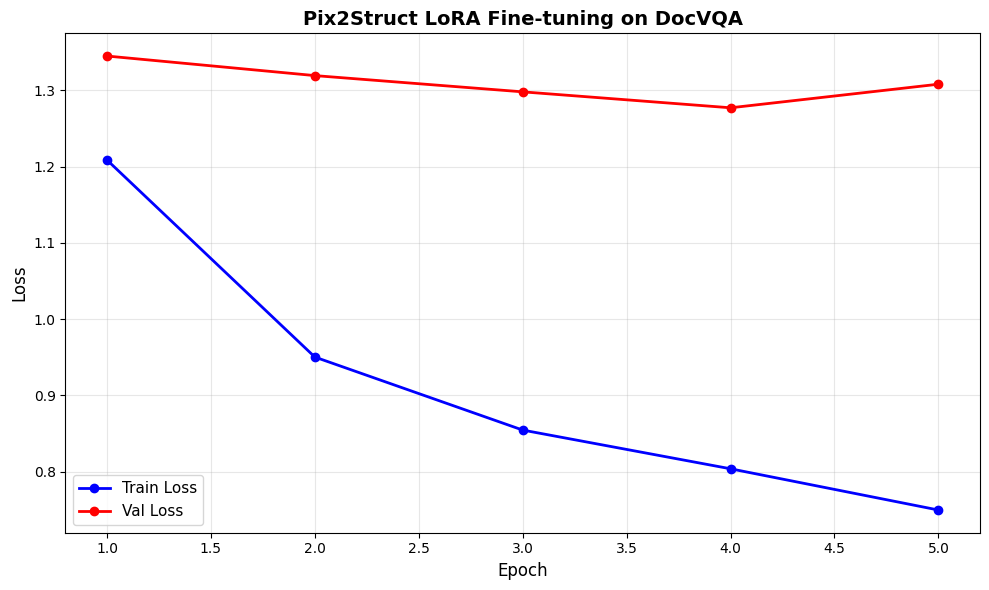

✓ Saved


In [6]:
# ============================================================
# CELL 6: Plot training curves
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
ax.plot(epochs, val_losses, 'r-o', label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Pix2Struct LoRA Fine-tuning on DocVQA', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

In [7]:
# ============================================================
# CELL 7: Evaluate fine-tuned Pix2Struct on financial test set
# ============================================================

from peft import PeftModel
from PIL import Image
from tqdm import tqdm
import numpy as np
import time

# Load financial test set
with open(os.path.join(cfg.FINANCIAL_ANNOT, 'combined_financial_vqa_dataset_fixed_types.json'), 'r') as f:
    fin_data = json.load(f)

eval_pairs = []
for entry in fin_data:
    ticker = entry['ticker']
    fname = entry['image_path']
    img_path = os.path.join(cfg.FINANCIAL_IMGS, ticker, fname)
    if not os.path.exists(img_path):
        continue
    for q in entry['questions']:
        eval_pairs.append({
            'image_path': img_path,
            'ticker': ticker,
            'question': q['question'],
            'answer': q['answer'],
            'question_type': q['type'],
        })

print(f"✓ Financial test set: {len(eval_pairs)} QA pairs")

# --- Metrics ---
def normalized_levenshtein(s1, s2):
    s1, s2 = s1.lower().strip(), s2.lower().strip()
    if s1 == s2:
        return 1.0
    if len(s1) == 0 or len(s2) == 0:
        return 0.0
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return 1.0 - (dp[m][n] / max(m, n))

def compute_anls(prediction, ground_truth, threshold=0.5):
    if not prediction:
        return 0.0
    score = normalized_levenshtein(prediction, ground_truth)
    return score if score >= threshold else 0.0

def compute_exact_match(prediction, ground_truth):
    return float(prediction.lower().strip() == ground_truth.lower().strip())

# --- Predict with fine-tuned model ---
def finetuned_predict(image, question):
    inputs = processor(
        images=image, text=question,
        return_tensors="pt", max_patches=MAX_PATCHES
    ).to('cuda')

    with torch.no_grad():
        generated = model.base_model.model.generate(
            flattened_patches=inputs.flattened_patches,
            attention_mask=inputs.attention_mask,
            max_new_tokens=256,
        )
    return processor.decode(generated[0], skip_special_tokens=True)

# --- Run evaluation ---
print(f"\nEvaluating fine-tuned Pix2Struct on financial test set...")
print("=" * 60)

results = []
anls_scores = []
em_scores = []
type_anls = {}
type_em = {}

start = time.time()

for pair in tqdm(eval_pairs, desc="Fine-tuned Pix2Struct"):
    try:
        img = Image.open(pair['image_path']).convert('RGB')
        prediction = finetuned_predict(img, pair['question'])
    except Exception as e:
        prediction = ""

    anls = compute_anls(prediction, pair['answer'])
    em = compute_exact_match(prediction, pair['answer'])

    anls_scores.append(anls)
    em_scores.append(em)

    qtype = pair['question_type']
    if qtype not in type_anls:
        type_anls[qtype] = []
        type_em[qtype] = []
    type_anls[qtype].append(anls)
    type_em[qtype].append(em)

    results.append({
        'ticker': pair['ticker'],
        'question': pair['question'],
        'ground_truth': pair['answer'],
        'prediction': prediction,
        'question_type': qtype,
        'anls': anls,
        'exact_match': em,
    })

elapsed = time.time() - start

print(f"\nFINE-TUNED Pix2Struct RESULTS")
print("=" * 60)
print(f"  Overall ANLS:  {np.mean(anls_scores):.4f}")
print(f"  Overall EM:    {np.mean(em_scores):.4f}")
print(f"  Time: {elapsed:.0f}s")

print(f"\n  Per question type:")
for qtype in sorted(type_anls.keys()):
    a = np.mean(type_anls[qtype])
    e = np.mean(type_em[qtype])
    n = len(type_anls[qtype])
    print(f"    {qtype:25s}: ANLS={a:.4f}  EM={e:.4f}  (n={n})")

# Compare with zero-shot
print(f"\n  vs Zero-shot Pix2Struct (0.137 ANLS):")
print(f"    Change: {np.mean(anls_scores) - 0.137:+.4f} ANLS")

# Save
ft_results = {
    'model': 'Pix2Struct LoRA fine-tuned',
    'overall_anls': float(np.mean(anls_scores)),
    'overall_em': float(np.mean(em_scores)),
    'per_type': {t: {'anls': float(np.mean(v)), 'em': float(np.mean(type_em[t])), 'n': len(v)}
                 for t, v in type_anls.items()},
    'per_example': results,
}
with open(os.path.join(cfg.OUTPUTS_DIR, 'final_pix2struct_finetuned_results.json'), 'w') as f:
    json.dump(ft_results, f, indent=2)
print("✓ Saved")

✓ Financial test set: 397 QA pairs

Evaluating fine-tuned Pix2Struct on financial test set...


Fine-tuned Pix2Struct: 100%|██████████| 397/397 [05:11<00:00,  1.28it/s]


FINE-TUNED Pix2Struct RESULTS
  Overall ANLS:  0.0844
  Overall EM:    0.0302
  Time: 311s

  Per question type:
    chart_interpretation     : ANLS=0.1324  EM=0.0588  (n=17)
    extractive               : ANLS=0.1189  EM=0.0453  (n=243)
    layout_understanding     : ANLS=0.0089  EM=0.0000  (n=72)
    numerical_reasoning      : ANLS=0.0262  EM=0.0000  (n=65)

  vs Zero-shot Pix2Struct (0.137 ANLS):
    Change: -0.0526 ANLS
✓ Saved


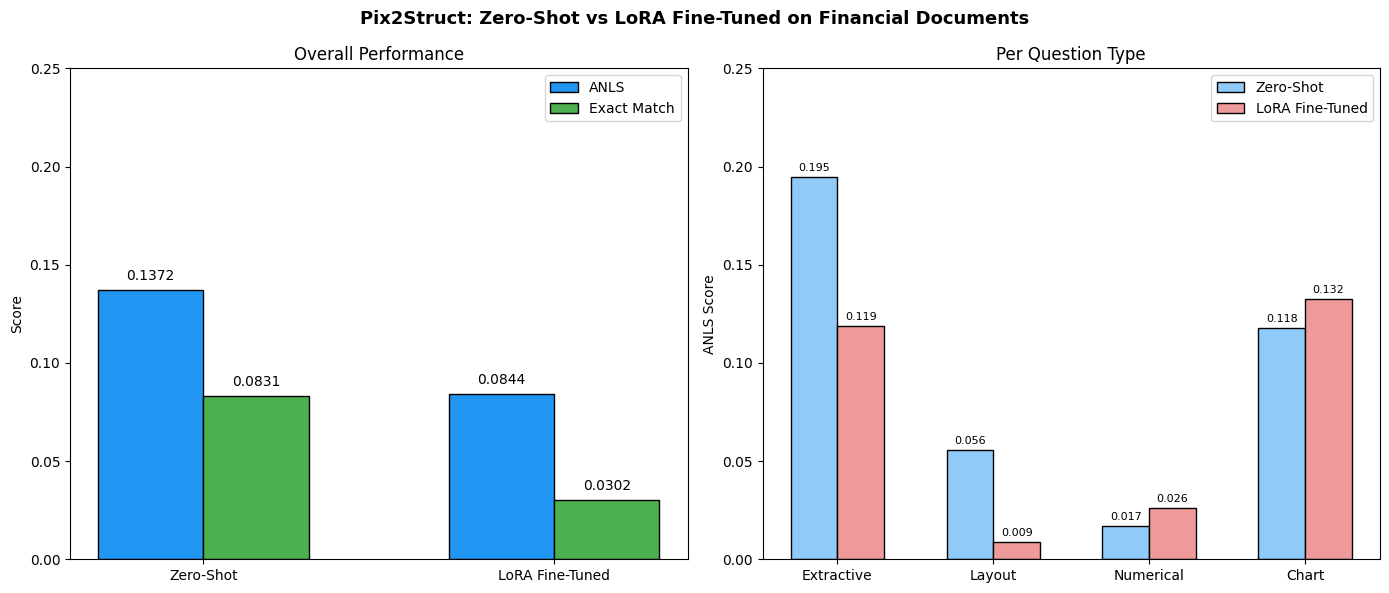

✓ Saved


In [8]:
# ============================================================
# CELL 8: Zero-shot vs Fine-tuned Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pix2Struct: Zero-Shot vs LoRA Fine-Tuned on Financial Documents',
             fontsize=13, fontweight='bold')

# --- Plot 1: Overall comparison ---
ax = axes[0]
models = ['Zero-Shot', 'LoRA Fine-Tuned']
anls_vals = [0.1372, 0.0844]
em_vals = [0.0831, 0.0302]

x = np.arange(2)
width = 0.3
bars1 = ax.bar(x - width/2, anls_vals, width, label='ANLS', color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, em_vals, width, label='Exact Match', color='#4CAF50', edgecolor='black')
for bar, val in zip(bars1, anls_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontsize=10)
for bar, val in zip(bars2, em_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Overall Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.25)

# --- Plot 2: Per question type ---
ax = axes[1]
qtypes = ['Extractive', 'Layout', 'Numerical', 'Chart']
zs_anls = [0.1949, 0.0556, 0.0169, 0.1176]
ft_anls = [0.1189, 0.0089, 0.0262, 0.1324]

x = np.arange(len(qtypes))
width = 0.3
bars1 = ax.bar(x - width/2, zs_anls, width, label='Zero-Shot', color='#90CAF9', edgecolor='black')
bars2 = ax.bar(x + width/2, ft_anls, width, label='LoRA Fine-Tuned', color='#EF9A9A', edgecolor='black')
for bar, val in zip(bars1, zs_anls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, ft_anls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.3f}', ha='center', fontsize=8)
ax.set_ylabel('ANLS Score')
ax.set_title('Per Question Type')
ax.set_xticks(x)
ax.set_xticklabels(qtypes)
ax.legend()
ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'finetuning_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")